In [1]:
import pandas as pd
import numpy as np
from scipy.fftpack import fft,fftshift
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
import xarray as xr
import sympy
import os
from fractions import Fraction
from model.lsclib import caseClass, find_caseKey
from scipy import linalg
import glob
# import netCDF4 as nc
# from netCDF4 import Dataset
%matplotlib inline

In [2]:
# File
path_data = "G:/LSCDynRegime_cxy/data/"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

In [3]:
# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
"""
ustar (m/s)  kH
0.01214      2.5/nan
0.00857      5.0
0.00605      10.0
"""

'\nustar (m/s)  kH\n0.01214      2.5/nan\n0.00857      5.0\n0.00605      10.0\n'

In [4]:
# Data
key_col = ["dissip+", "avg_u+"]
nz = 101
H = 25 # m
Δt = 120 # second
dz_nd = 1 / (nz - 1)

In [5]:
## Create case containers
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case

In [6]:
## Read all data
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for case in case_all:
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['dissip+'] = data_col['dissip+']
    case_all[case].data['avg_ub+'] = data_col['avg_u+'][50]
    case_all[case].data['avg_us+'] = data_col['avg_u+'][0]
    case_all[case].data = case_all[case].data.mean()
    case_all[case].data['avg_u+'] = data_col['avg_u+']

In [7]:
## Re-organize data to array-type for fitting
# Declare data variable
ndim = len(case_all)
dissip_les = np.zeros(ndim)
ub = np.zeros(ndim)
us = np.zeros(ndim)
u = np.zeros((ndim,101))

# Extract data values from data containers
for ic, case in enumerate(case_all):
    dissip_les[ic] = case_all[case].data['dissip+']
    ub[ic] = case_all[case].data['avg_ub+']
    us[ic] = case_all[case].data['avg_us+']
    u[ic] = case_all[case].data['avg_u+']

In [8]:
chi=np.array([0.5,0.5,0.5,
              0.75,0.75,0.75,
              1,1,1,
              4/3,4/3,4/3,
              2,2,2,
              0.5,0.5,0.5,
              0.75,0.75,0.75,
              1,1,1,
              4/3,4/3,4/3,
              2,2,2,
              0.5,0.75,1,4/3,2])
ustar_s=np.array([0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214,0.01214,0.01214,0.01214,0.01214])#kH2.5 kH5 kH10
ustar_b=ustar_s/chi

In [9]:
X=(ustar_b**2-ustar_s**2)*(ub*ustar_s)+(ustar_s**2)*(us*ustar_s)
Y=dissip_les*(ustar_s**3)

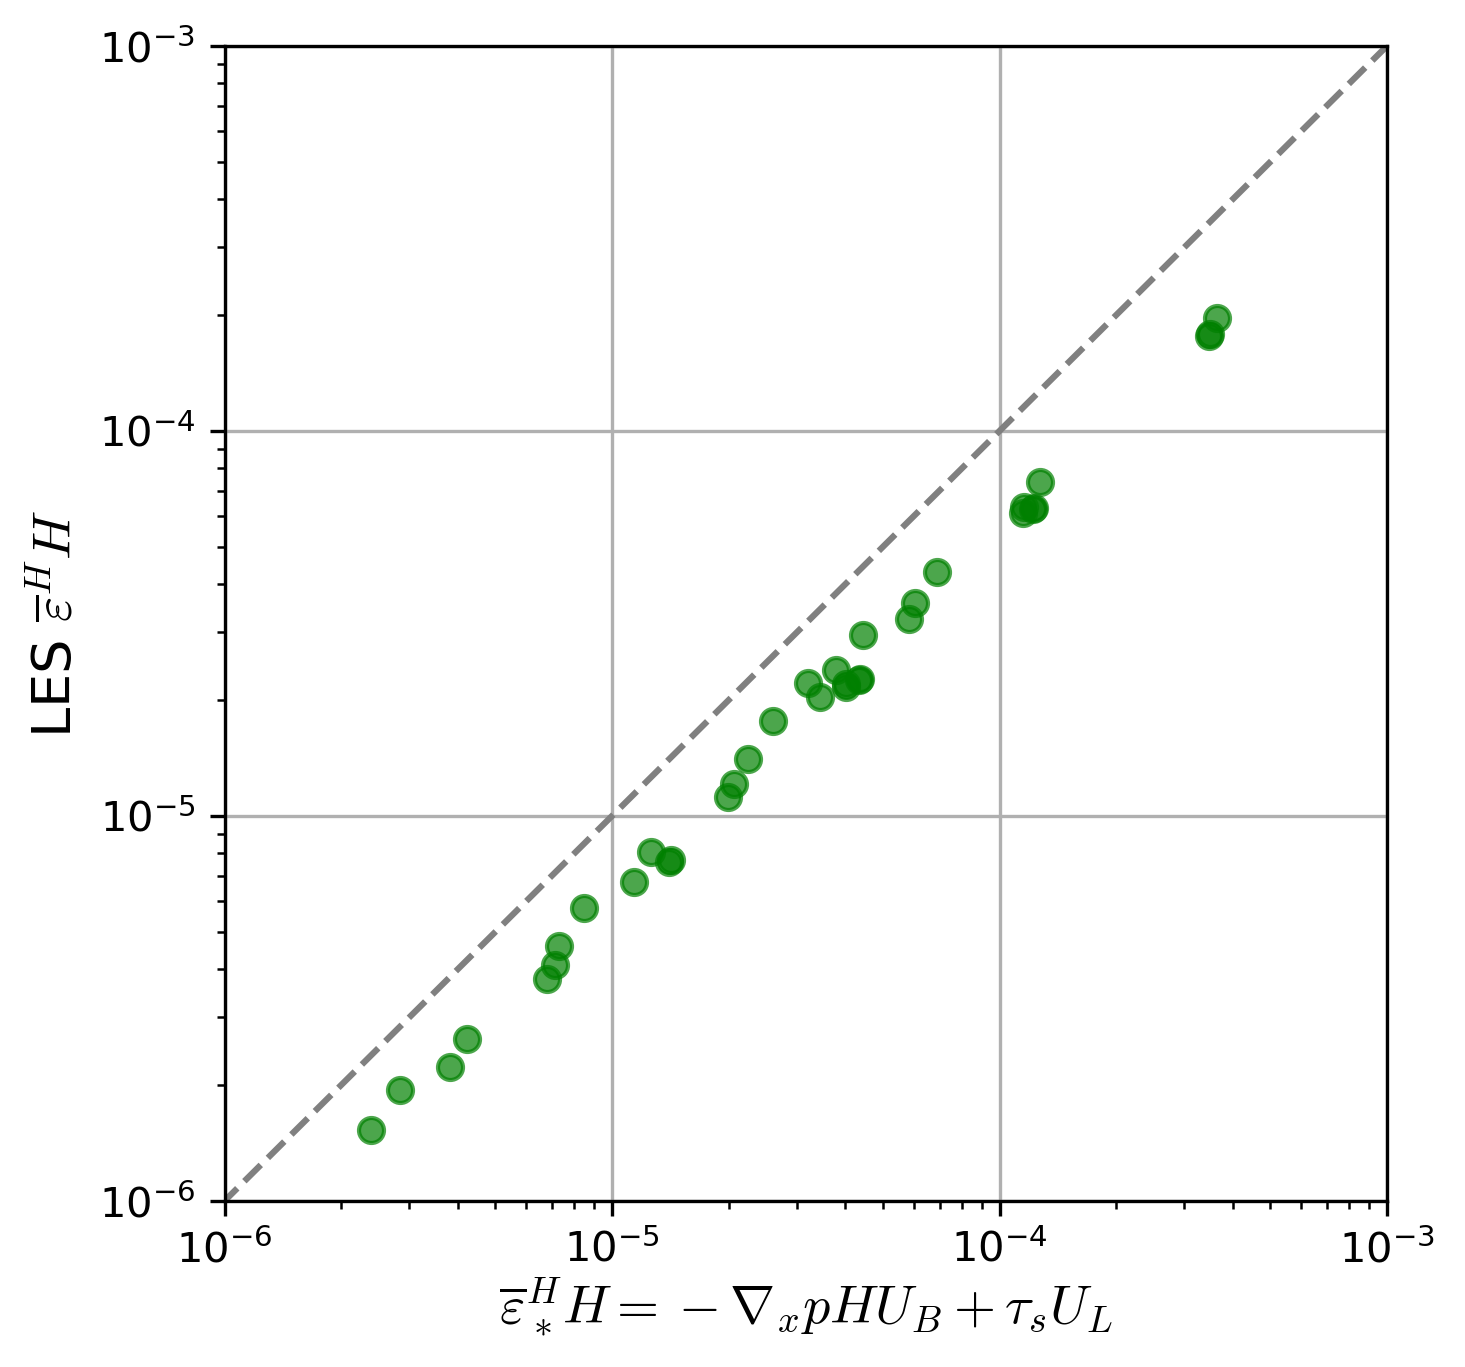

In [13]:
plt.rcParams['mathtext.fontset'] = 'cm'
ifig=0
fig=plt.figure(ifig,figsize=(5,5),dpi=300)
min=1e-6
max=1e-3

ax1=fig.add_subplot(111)
# ax1.scatter(X,Y)
ax1.loglog(X,Y,linewidth =1.5, color='green',
             linestyle='none',label='test',alpha=0.7,marker='o')
diag_line = ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_ylim([min,max])
ax1.set_xlim([min,max])
ax1.set_ylabel(r'LES $\overline{\varepsilon}^H H$',fontsize=13)
# ax1.set_xlabel("$\nabla_xpHU_B + \tau_{s}U_L$")
ax1.set_xlabel(r"$\overline{\varepsilon}_*^H H = -\nabla_x p H U_B + \tau_s U_L$",fontsize=13,labelpad=1)
ax1.grid(True)


fig.savefig('energy balance',bbox_inches='tight')
plt.show()


In [43]:
z=np.arange(-nz+1,1,1)/nz*H
z0=0.01
z01=0.001
z02=0.1
κ = 0.4

/tmp/ipykernel_160845/4264032641.py:12: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[0]/κ*np.log(z[::-1]/-z0)/ustar_s[0],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/4264032641.py:13: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[3]/κ*np.log(z[::-1]/-z0)/ustar_s[3],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/4264032641.py:14: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[6]/κ*np.log(z[::-1]/-z0)/ustar_s[6],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/4264032641.py:15: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[9]/κ*np.log(z[::-1]/-z0)/ustar_s[9],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/4264032641.py:16: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[12]/κ*np.log(z[::-1]/-z0)/ustar_s[12],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
/tm

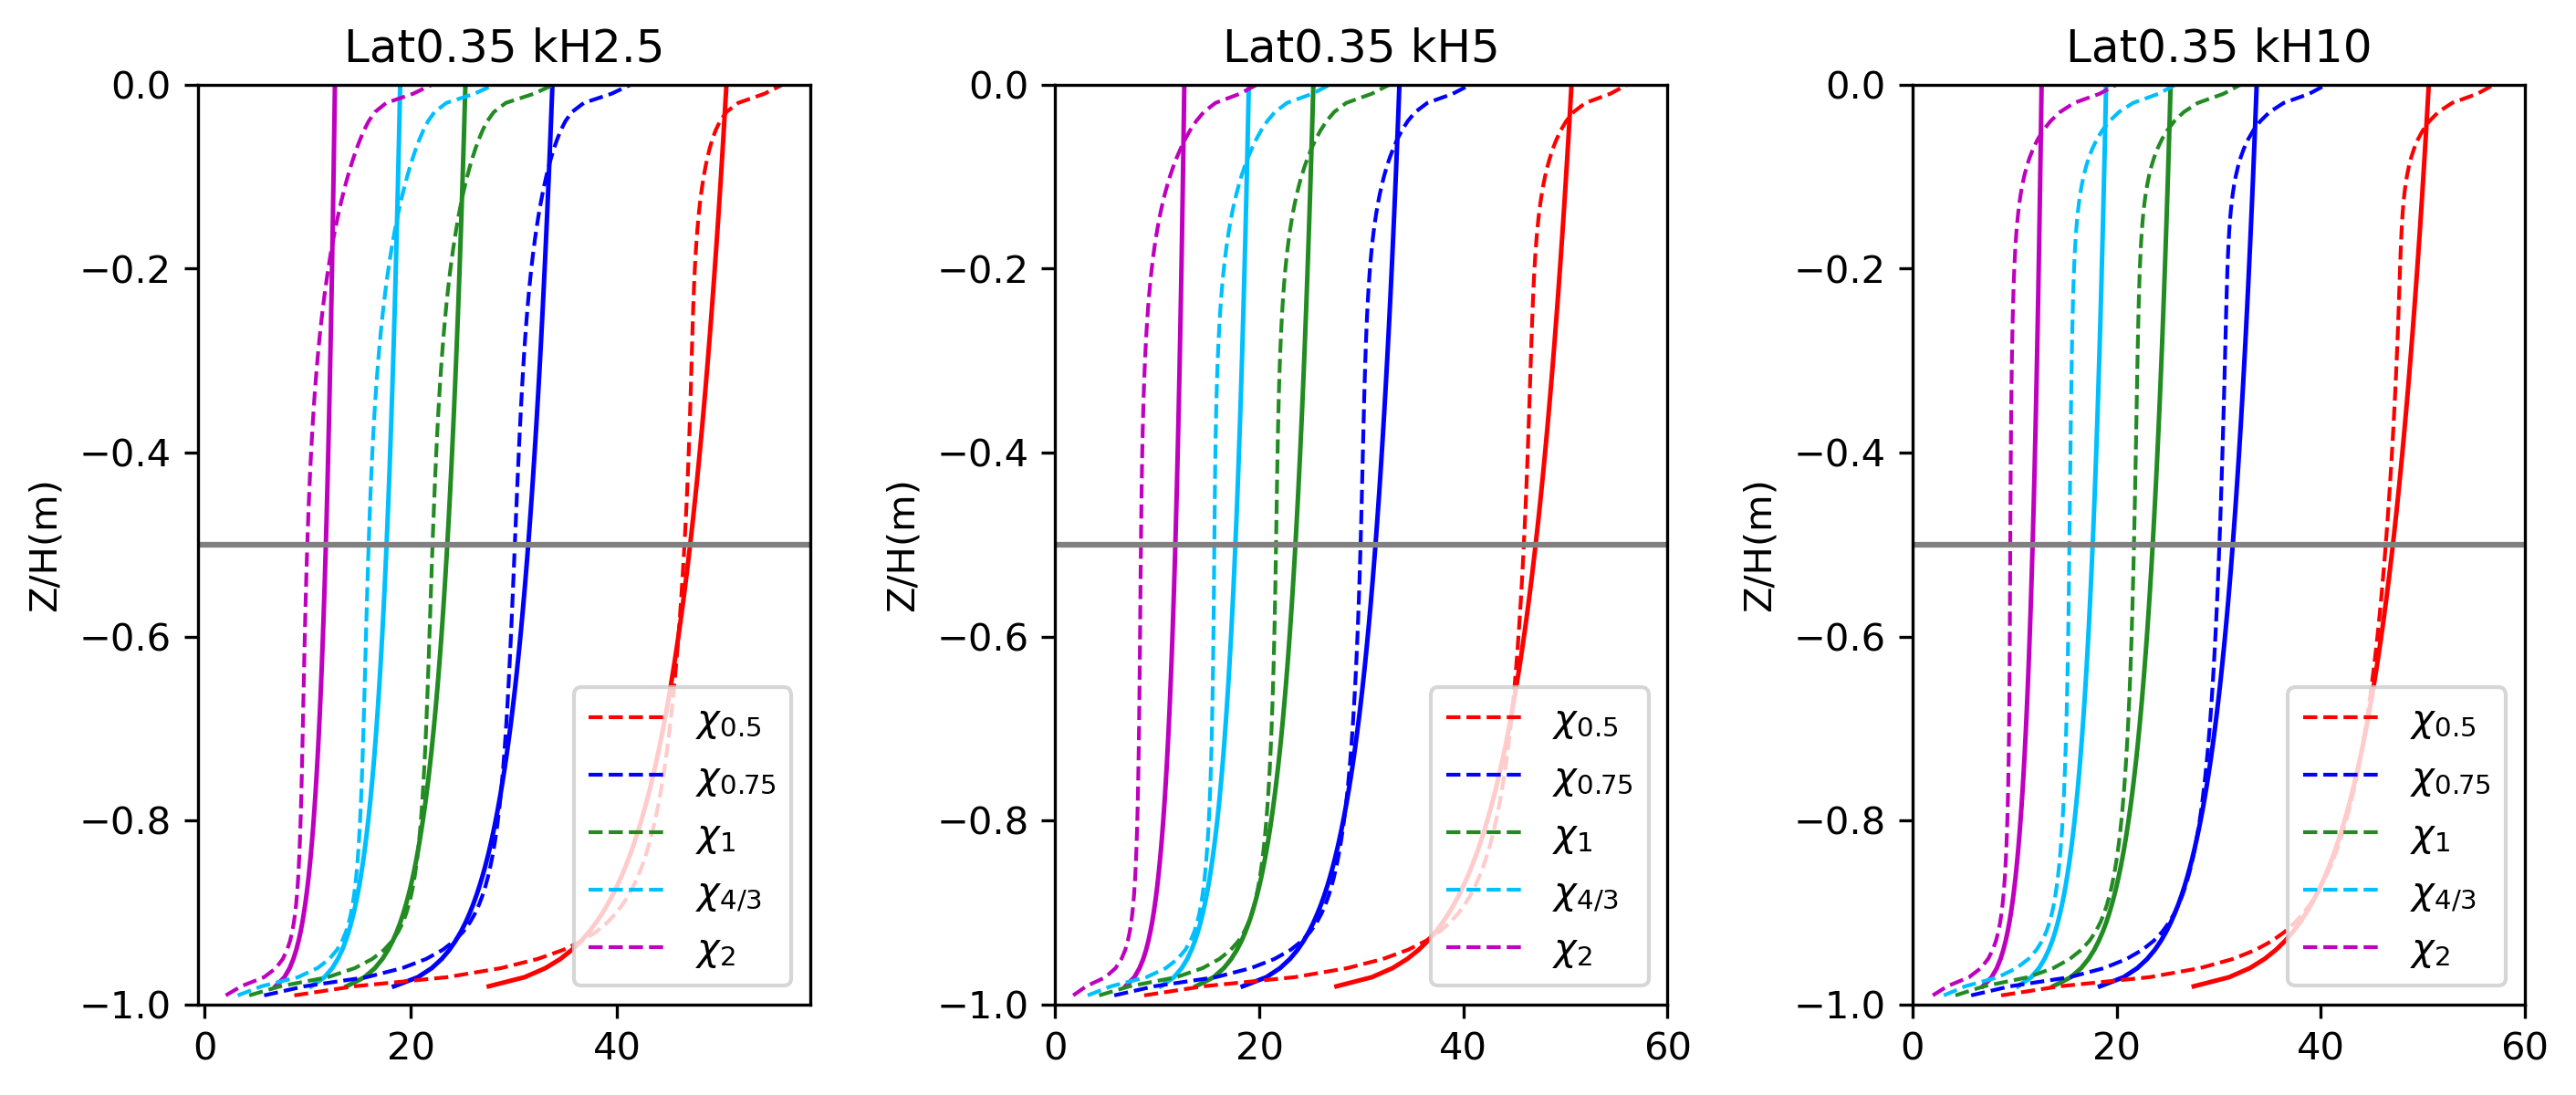

In [28]:
ifig=1
fig=plt.figure(ifig,figsize=(10,4),dpi=300)
gs=fig.add_gridspec(1,3,left=0.05,right=0.90,bottom=0.12,top=0.96,hspace=0.2,wspace=0.4)
#plt.suptitle("Lat0.7",fontsize=12,x=0.47, y=1)

labels=['$log kH_{2.5}$','$log kH_{5}$','$log kH_{10}$','$kH_{NaN}$']
labels2=['$\chi_{0.5}$','$\chi_{0.75}$','$\chi_{1}$','$\chi_{4/3}$','$\chi_{2}$']
colors=['k','red','blue','forestgreen','deepskyblue','m']
lines=['-','--']

ax1=fig.add_subplot(gs[0])
ax1.plot(ustar_b[0]/κ*np.log(z[::-1]/-z0)/ustar_s[0],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[3]/κ*np.log(z[::-1]/-z0)/ustar_s[3],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[6]/κ*np.log(z[::-1]/-z0)/ustar_s[6],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[9]/κ*np.log(z[::-1]/-z0)/ustar_s[9],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[12]/κ*np.log(z[::-1]/-z0)/ustar_s[12],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
ax1.plot(u[0,::-1],z/H,color=colors[1],linewidth=1,linestyle=lines[1],label=labels2[0])
ax1.plot(u[3,::-1],z/H,color=colors[2],linewidth=1,linestyle=lines[1],label=labels2[1])
ax1.plot(u[6,::-1],z/H,color=colors[3],linewidth=1,linestyle=lines[1],label=labels2[2])
ax1.plot(u[9,::-1],z/H,color=colors[4],linewidth=1,linestyle=lines[1],label=labels2[3])
ax1.plot(u[12,::-1],z/H,color=colors[5],linewidth=1,linestyle=lines[1],label=labels2[4])
ax1.set_ylabel('Z/H(m)')

ax2=fig.add_subplot(gs[1])
ax2.plot(ustar_b[1]/κ*np.log(z[::-1]/-z0)/ustar_s[1],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[4]/κ*np.log(z[::-1]/-z0)/ustar_s[4],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[7]/κ*np.log(z[::-1]/-z0)/ustar_s[7],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[10]/κ*np.log(z[::-1]/-z0)/ustar_s[10],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[13]/κ*np.log(z[::-1]/-z0)/ustar_s[13],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
ax2.plot(u[1,::-1],z/H,color=colors[1],linewidth=1,linestyle=lines[1],label=labels2[0])
ax2.plot(u[4,::-1],z/H,color=colors[2],linewidth=1,linestyle=lines[1],label=labels2[1])
ax2.plot(u[7,::-1],z/H,color=colors[3],linewidth=1,linestyle=lines[1],label=labels2[2])
ax2.plot(u[10,::-1],z/H,color=colors[4],linewidth=1,linestyle=lines[1],label=labels2[3])
ax2.plot(u[13,::-1],z/H,color=colors[5],linewidth=1,linestyle=lines[1],label=labels2[4])
ax2.set_ylabel('Z/H(m)')

ax3=fig.add_subplot(gs[2])
ax3.plot(ustar_b[2]/κ*np.log(z[::-1]/-z0)/ustar_s[2],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[5]/κ*np.log(z[::-1]/-z0)/ustar_s[5],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[8]/κ*np.log(z[::-1]/-z0)/ustar_s[8],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[11]/κ*np.log(z[::-1]/-z0)/ustar_s[11],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[14]/κ*np.log(z[::-1]/-z0)/ustar_s[14],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
ax3.plot(u[2,::-1],z/H,color=colors[1],linewidth=1,linestyle=lines[1],label=labels2[0])
ax3.plot(u[5,::-1],z/H,color=colors[2],linewidth=1,linestyle=lines[1],label=labels2[1])
ax3.plot(u[8,::-1],z/H,color=colors[3],linewidth=1,linestyle=lines[1],label=labels2[2])
ax3.plot(u[11,::-1],z/H,color=colors[4],linewidth=1,linestyle=lines[1],label=labels2[3])
ax3.plot(u[14,::-1],z/H,color=colors[5],linewidth=1,linestyle=lines[1],label=labels2[4])
ax3.set_ylabel('Z/H(m)')


ax1.axhline(y=-0.5, xmin=0, xmax=1,c='grey')
ax2.axhline(y=-0.5, xmin=0, xmax=1,c='grey')
ax3.axhline(y=-0.5, xmin=0, xmax=1,c='grey')

#ax1.set_xlim((0,60))
ax2.set_xlim((0,60))
ax3.set_xlim((0,60))

ax1.set_ylim((-1,0))
ax2.set_ylim((-1,0))
ax3.set_ylim((-1,0))

ax1.set_title('Lat0.35 kH2.5')
ax2.set_title('Lat0.35 kH5')
ax3.set_title('Lat0.35 kH10')

ax1.legend()
ax2.legend()
ax3.legend()
fig.savefig('z0_0001_035',bbox_inches='tight')
plt.show()

/tmp/ipykernel_160845/1676966621.py:12: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[15]/κ*np.log(z[::-1]/-z0)/ustar_s[15],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/1676966621.py:13: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[18]/κ*np.log(z[::-1]/-z0)/ustar_s[18],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/1676966621.py:14: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[21]/κ*np.log(z[::-1]/-z0)/ustar_s[21],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/1676966621.py:15: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[24]/κ*np.log(z[::-1]/-z0)/ustar_s[24],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
/tmp/ipykernel_160845/1676966621.py:16: RuntimeWarning: divide by zero encountered in log
  ax1.plot(ustar_b[27]/κ*np.log(z[::-1]/-z0)/ustar_s[27],z/H,color=colors[5],linewidth=1.2,linestyle=lines

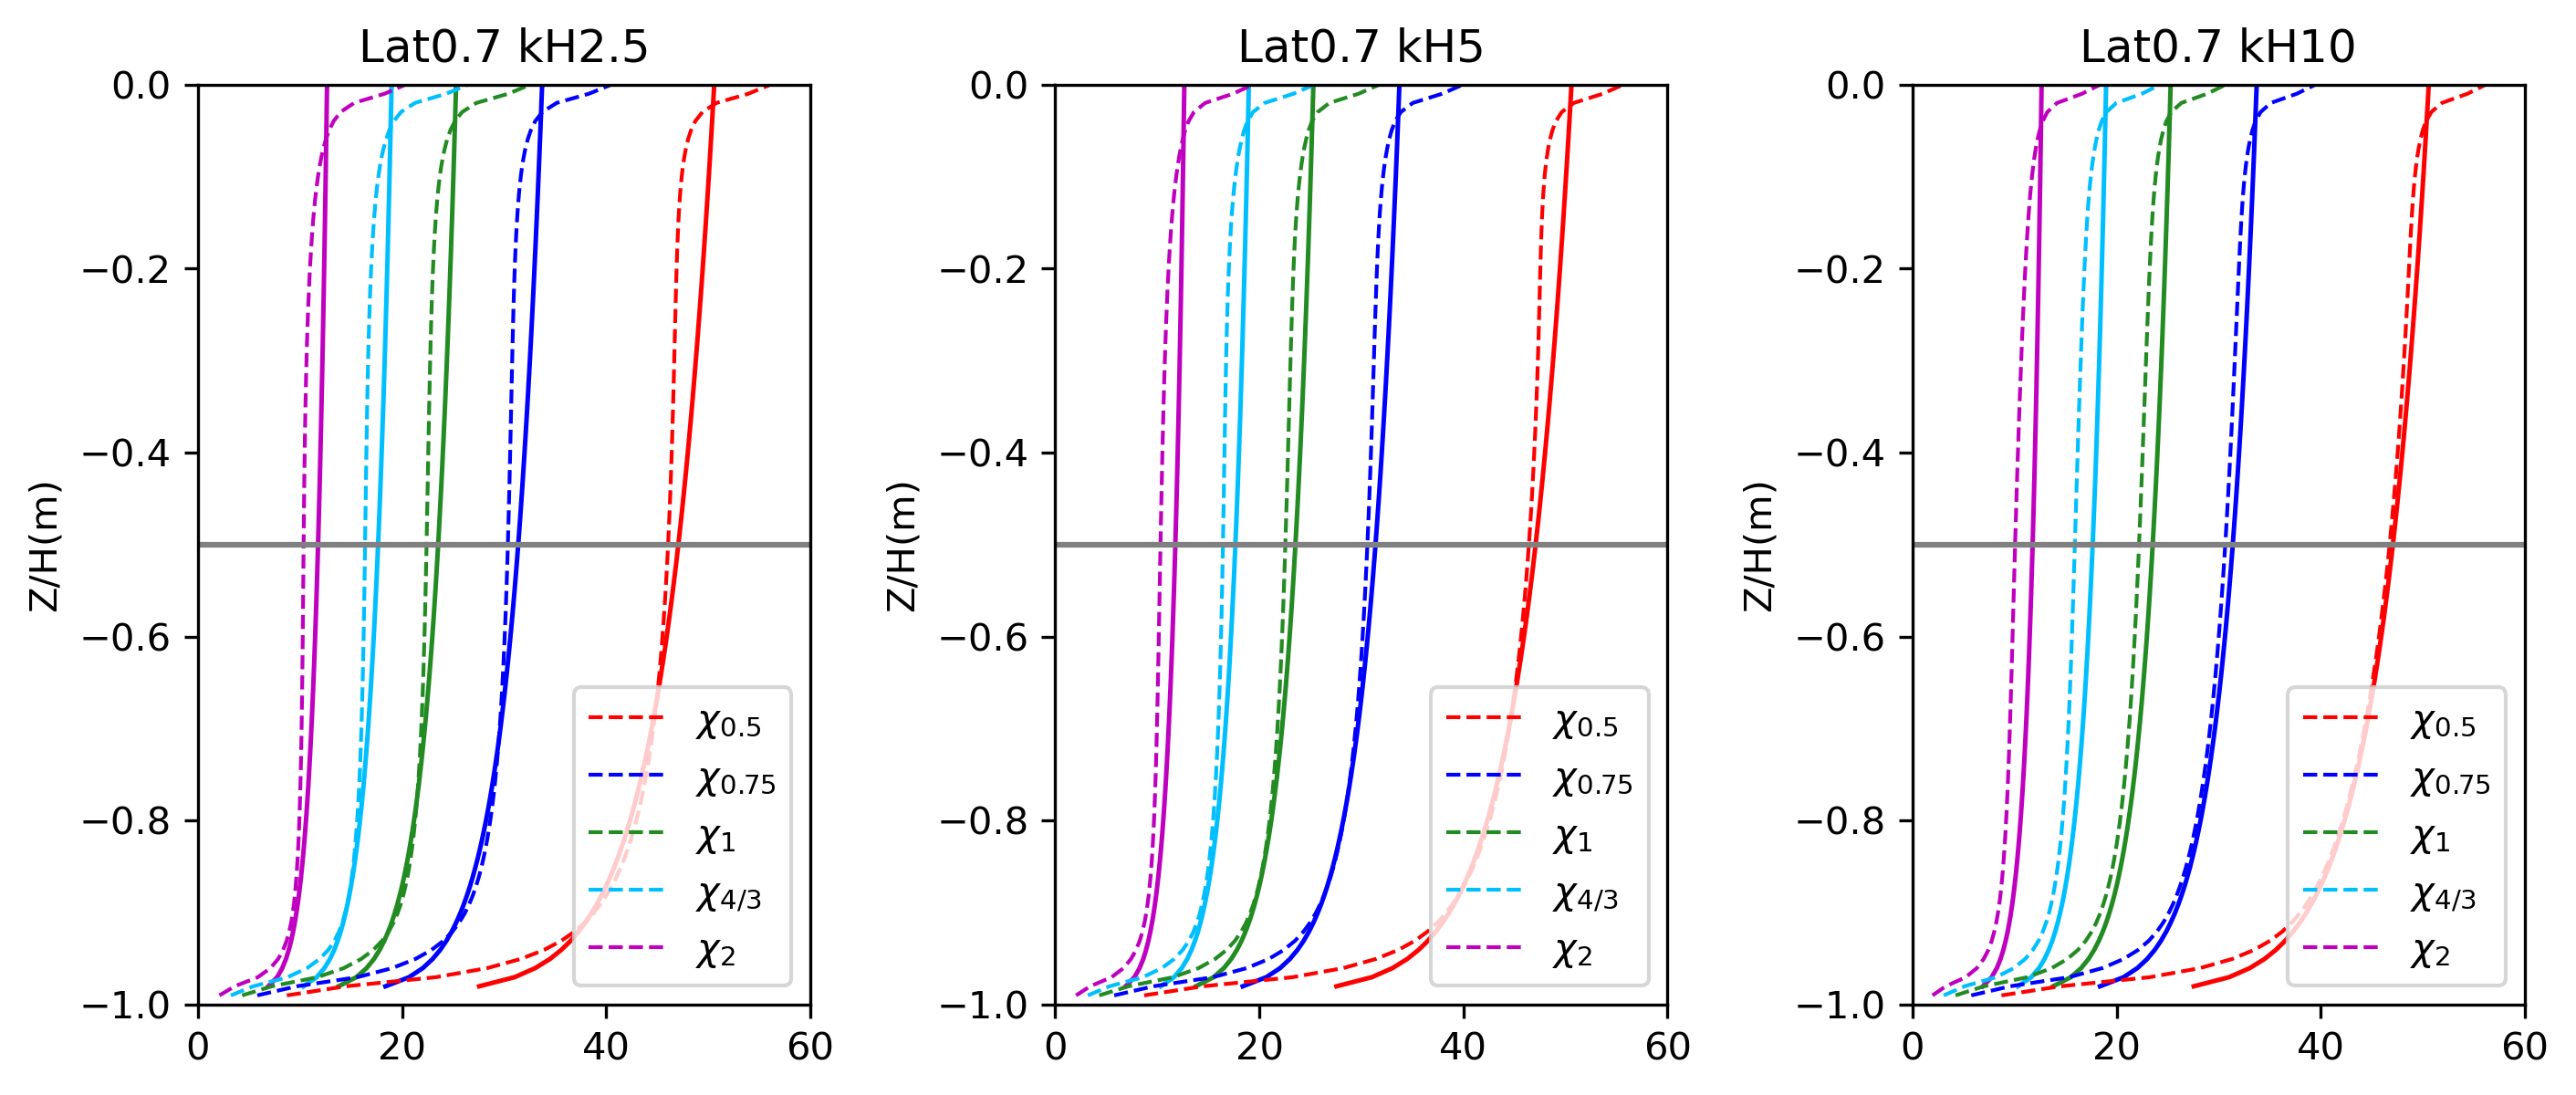

In [29]:
ifig=1
fig=plt.figure(ifig,figsize=(10,4),dpi=300)
gs=fig.add_gridspec(1,3,left=0.05,right=0.90,bottom=0.12,top=0.96,hspace=0.2,wspace=0.4)
#plt.suptitle("Lat0.7",fontsize=12,x=0.47, y=1)

labels=['$log kH_{2.5}$','$log kH_{5}$','$log kH_{10}$','$kH_{NaN}$']
labels2=['$\chi_{0.5}$','$\chi_{0.75}$','$\chi_{1}$','$\chi_{4/3}$','$\chi_{2}$']
colors=['k','red','blue','forestgreen','deepskyblue','m']
lines=['-','--']

ax1=fig.add_subplot(gs[0])
ax1.plot(ustar_b[15]/κ*np.log(z[::-1]/-z0)/ustar_s[15],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[18]/κ*np.log(z[::-1]/-z0)/ustar_s[18],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[21]/κ*np.log(z[::-1]/-z0)/ustar_s[21],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[24]/κ*np.log(z[::-1]/-z0)/ustar_s[24],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
ax1.plot(ustar_b[27]/κ*np.log(z[::-1]/-z0)/ustar_s[27],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
ax1.plot(u[15,::-1],z/H,color=colors[1],linewidth=1,linestyle=lines[1],label=labels2[0])
ax1.plot(u[18,::-1],z/H,color=colors[2],linewidth=1,linestyle=lines[1],label=labels2[1])
ax1.plot(u[21,::-1],z/H,color=colors[3],linewidth=1,linestyle=lines[1],label=labels2[2])
ax1.plot(u[24,::-1],z/H,color=colors[4],linewidth=1,linestyle=lines[1],label=labels2[3])
ax1.plot(u[27,::-1],z/H,color=colors[5],linewidth=1,linestyle=lines[1],label=labels2[4])
ax1.set_ylabel('Z/H(m)')

ax2=fig.add_subplot(gs[1])
ax2.plot(ustar_b[16]/κ*np.log(z[::-1]/-z0)/ustar_s[16],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[19]/κ*np.log(z[::-1]/-z0)/ustar_s[19],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[22]/κ*np.log(z[::-1]/-z0)/ustar_s[22],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[25]/κ*np.log(z[::-1]/-z0)/ustar_s[25],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
ax2.plot(ustar_b[28]/κ*np.log(z[::-1]/-z0)/ustar_s[28],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
ax2.plot(u[16,::-1],z/H,color=colors[1],linewidth=1,linestyle=lines[1],label=labels2[0])
ax2.plot(u[19,::-1],z/H,color=colors[2],linewidth=1,linestyle=lines[1],label=labels2[1])
ax2.plot(u[22,::-1],z/H,color=colors[3],linewidth=1,linestyle=lines[1],label=labels2[2])
ax2.plot(u[25,::-1],z/H,color=colors[4],linewidth=1,linestyle=lines[1],label=labels2[3])
ax2.plot(u[28,::-1],z/H,color=colors[5],linewidth=1,linestyle=lines[1],label=labels2[4])
ax2.set_ylabel('Z/H(m)')

ax3=fig.add_subplot(gs[2])
ax3.plot(ustar_b[17]/κ*np.log(z[::-1]/-z0)/ustar_s[17],z/H,color=colors[1],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[20]/κ*np.log(z[::-1]/-z0)/ustar_s[20],z/H,color=colors[2],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[23]/κ*np.log(z[::-1]/-z0)/ustar_s[23],z/H,color=colors[3],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[26]/κ*np.log(z[::-1]/-z0)/ustar_s[26],z/H,color=colors[4],linewidth=1.2,linestyle=lines[0])
ax3.plot(ustar_b[29]/κ*np.log(z[::-1]/-z0)/ustar_s[29],z/H,color=colors[5],linewidth=1.2,linestyle=lines[0])
ax3.plot(u[17,::-1],z/H,color=colors[1],linewidth=1,linestyle=lines[1],label=labels2[0])
ax3.plot(u[20,::-1],z/H,color=colors[2],linewidth=1,linestyle=lines[1],label=labels2[1])
ax3.plot(u[23,::-1],z/H,color=colors[3],linewidth=1,linestyle=lines[1],label=labels2[2])
ax3.plot(u[26,::-1],z/H,color=colors[4],linewidth=1,linestyle=lines[1],label=labels2[3])
ax3.plot(u[29,::-1],z/H,color=colors[5],linewidth=1,linestyle=lines[1],label=labels2[4])
ax3.set_ylabel('Z/H(m)')

ax1.axhline(y=-0.5, xmin=0, xmax=1,c='grey')
ax2.axhline(y=-0.5, xmin=0, xmax=1,c='grey')
ax3.axhline(y=-0.5, xmin=0, xmax=1,c='grey')

ax1.set_xlim((0,60))
ax2.set_xlim((0,60))
ax3.set_xlim((0,60))

ax1.set_ylim((-1,0))
ax2.set_ylim((-1,0))
ax3.set_ylim((-1,0))

ax1.set_title('Lat0.7 kH2.5')
ax2.set_title('Lat0.7 kH5')
ax3.set_title('Lat0.7 kH10')

ax1.legend()
ax2.legend()
ax3.legend()
fig.savefig('z0_0001_07',bbox_inches='tight')
plt.show()